In [32]:
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from langchain.tools import tool
load_dotenv()

if os.environ['GOOGLE_API_KEY'] == "":
    raise ValueError("GOOGLE_API_KEY is not set in the .env file.")
else:
    print("GOOGLE_API_KEY is set correctly.")

GOOGLE_API_KEY is set correctly.


In [33]:
llm = ChatGoogleGenerativeAI(model="gemini-3.5-flash",)
llm

ChatGoogleGenerativeAI(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.13', 'langchain-google-genai': '4.2.6'}}, output_version=None, profile={'name': 'Gemini 3.5 Flash', 'release_date': '2026-05-19', 'last_updated': '2026-05-19', 'open_weights': False, 'max_input_tokens': 1048576, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': True, 'pdf_inputs': True, 'video_inputs': True, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'image_tool_message': True, 'tool_choice': True}, google_api_key=SecretStr('**********'), location=None, model='gemini-3.5-flash', temperature=1.0, client=<google.genai.client.Client object at 0x000001FCFA32BEE0>, default_metadata=(), model_kwargs={})

In [34]:
from langchain_community.tools import DuckDuckGoSearchResults

@tool
def search_trending_news(topic: str):
    """Use this tool to search for latest news on DuckDuckGo for a given topic and returns the results."""
    search = DuckDuckGoSearchResults()
    return search.invoke(f"Latest news on {topic}?")

In [35]:
from langchain_community.retrievers import ArxivRetriever

@tool
def arxiv_retriever(query: str):
    """Use this tool to retrieve documents from arXiv based on a query."""
    retriever = ArxivRetriever( load_max_docs=2, get_ful_documents=True, )
    return retriever.invoke(query)

In [36]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

@tool
def wikipedia_query(query: str):
    """Use this tool to query Wikipedia for information."""
    wikipedia = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
    return wikipedia.invoke(query)

# **Custom Tool**

In [37]:
@tool
def personal_info(name: str):
    """Use this tool to get personal information about Alice, Bob or Charlie."""
    info = {
        "Alice": "Alice is a software engineer from San Francisco.",
        "Bob": "Bob is a data scientist from New York.",
        "Charlie": "Charlie is a product manager from Seattle.",
    }
    return info.get(name, "Person not found.")

# **Tool binding**

In [38]:
tools = [search_trending_news, arxiv_retriever, wikipedia_query, personal_info]

llm_with_tools = llm.bind_tools(tools)

In [39]:
response = llm_with_tools.invoke("Can you tell me the latest news on AI?")

In [40]:
response.tool_calls

[{'name': 'search_trending_news',
  'args': {'topic': 'AI'},
  'id': 'yuv2ftzq',
  'type': 'tool_call'}]

# **LangGraph creation**

In [41]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    messages: List

In [42]:
from langchain_core.prompts import ChatPromptTemplate

def llm_node(state: graph_schema) -> graph_schema:
    messages = state["messages"]

    prompt = ChatPromptTemplate.from_messages(
        [
            ("system", "You are a helpful assistant that can use tools to answer questions."),
            ("human", "{input}"),
        ]
    )

    chain = prompt | llm_with_tools
    response = chain.invoke({"input": messages})

    state['messages'] = messages + [response]
    return state
    

In [43]:
# from langgraph.prebuilt import ToolNode    only for prebuilt nodes, we are building our own node here
from langchain_core.messages import ToolMessage

def tool_node(state: graph_schema) -> graph_schema:
    messages = state["messages"]

    tool_results = []
    tools_by_name = {tool.name: tool for tool in tools}

    for tool_call in messages[-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])

        tool_results.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))

    state['messages'] = messages + tool_results
    return state

In [44]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("llm_node", llm_node)
graph.add_node("tool_node", tool_node)

In [45]:
def if_tool_call(state: graph_schema) -> str:
    last_message = state['messages'][-1]

    if last_message.tool_calls:
        return "tool_node"
    else:
        return "end"

In [46]:
graph.add_edge(START, "llm_node")
graph.add_conditional_edges("llm_node", if_tool_call, {"tool_node": "tool_node", "end": END})
graph.add_edge("tool_node", "llm_node")
graph.add_edge("llm_node", END)

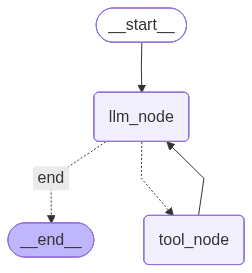

In [47]:
reAct_graph = graph.compile()

from IPython.display import Image, display
Image(reAct_graph.get_graph().draw_mermaid_png())

In [48]:
from langchain_core.messages import HumanMessage

reAct_graph.invoke({"messages": [HumanMessage(content="Can you tell me the latest news on AI?")]})

{'messages': [HumanMessage(content='Can you tell me the latest news on AI?', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'search_trending_news', 'arguments': '{"topic": "Artificial Intelligence"}'}, '__gemini_function_call_thought_signatures__': {'08ino1ce': 'EtACCs0CARFNMg/HUAVWg9LvM13sR1YHvdzqVg2ZHOCNwyS4biinEg9oVSza4W5VGys1x1XnfRG48rpyIhvDojYfihn10SVt/QwX6xpsekJlPYupeCO808Fj25wLAZ68zbfB8OrFBJ+cUqXwWcxJfSfER+yjuRsjrMc0faA1BIeU4a/1UqUGd/xDHhkqExi7XDqJOqM4fAcAmzKsJ0vhx7uG/BZbV7VIPsCXcUOi2FtQkFdk6jv8n7cxAZq1jNun0jPEtqFihi3by/Hm+G3ROZIZPLErGHEWoOJgUlhiz1sThDm88gFxWDzWnn6Fv3WY7MqSR1Zk//Ll57E6N23AobFdlLg9sp6ubsl3oQ7KS0DTAFOqdnTzPyDam/+56UfQpCn9JKlvXou1dXt+wyQzY26PIkLneN60qzKnNhTIYIxgeImrzRcu5BiXcb+rRORfrGk5'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019f5537-2f32-7692-98a1-d3e1ef97aa15-0', tool_calls=[{'name': 'sea